In [1]:
# 案例2：Logistic人口增长模型 - 中国现代人口分析
# 目标：使用Logistic S型增长模型分析中国1950-2020年人口数据

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
print("=" * 60)
print("案例2：Logistic人口增长模型 - 中国现代人口分析")
print("=" * 60)

案例2：Logistic人口增长模型 - 中国现代人口分析


In [4]:
# 1. 数据准备

In [5]:
# 中国1950-2020年人口数据（单位：亿）
years = np.array([1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020])
population = np.array([5.5, 6.7, 8.3, 9.9, 11.4, 12.7, 13.4, 14.1])

# 创建DataFrame
data = pd.DataFrame({
    'Year': years,
    'Population': population,
    'Time': years - 1950  # 以1950年为起点，时间单位：年
})

print("中国现代人口数据：")
print(data)

中国现代人口数据：
   Year  Population  Time
0  1950         5.5     0
1  1960         6.7    10
2  1970         8.3    20
3  1980         9.9    30
4  1990        11.4    40
5  2000        12.7    50
6  2010        13.4    60
7  2020        14.1    70


In [6]:
# 计算增长率变化
print("\n各decade增长率变化：")
for i in range(1, len(population)):
    growth_rate = (population[i] - population[i-1]) / population[i-1] / 10 * 100
    print(f"{years[i-1]}-{years[i]}：{growth_rate:.2f}%/年")

print("\n观察：增长率呈递减趋势，符合Logistic模型特征！")


各decade增长率变化：
1950-1960：2.18%/年
1960-1970：2.39%/年
1970-1980：1.93%/年
1980-1990：1.52%/年
1990-2000：1.14%/年
2000-2010：0.55%/年
2010-2020：0.52%/年

观察：增长率呈递减趋势，符合Logistic模型特征！


In [7]:
# 2. Logistic模型理论回顾
print("\n2. Logistic模型理论")
print("-" * 30)
print("微分方程：dN/dt = rN(1 - N/K)")
print("解析解：N(t) = K / (1 + A × e^(-rt))")
print("其中：A = (K - N₀) / N₀")
print("参数：N₀ = 初始人口，r = 内在增长率，K = 环境承载力")


2. Logistic模型理论
------------------------------
微分方程：dN/dt = rN(1 - N/K)
解析解：N(t) = K / (1 + A × e^(-rt))
其中：A = (K - N₀) / N₀
参数：N₀ = 初始人口，r = 内在增长率，K = 环境承载力


In [8]:
# 3. 定义Logistic函数
print("\n3. 定义Logistic模型函数")
print("-" * 30)

def logistic_model(t, K, r, t0):
    """
    Logistic人口增长模型
    
    参数：
    t: 时间数组
    K: 环境承载力
    r: 内在增长率
    t0: 时间偏移参数（用于调整拐点位置）
    
    返回：
    人口数量
    """
    return K / (1 + np.exp(-r * (t - t0)))

def logistic_standard(t, K, r, N0):
    """
    标准形式的Logistic模型
    N(t) = K / (1 + A * exp(-rt))
    其中 A = (K - N0) / N0
    """
    A = (K - N0) / N0
    return K / (1 + A * np.exp(-r * t))

print("函数定义完成！")


3. 定义Logistic模型函数
------------------------------
函数定义完成！


In [9]:
# 4. 参数估计 - 非线性拟合
print("\n4. 非线性参数估计")
print("-" * 30)

# 准备数据
t = data['Time'].values
N = data['Population'].values

# 设置初始猜测值（这很重要！）
# K: 环境承载力，估计为当前人口的1.1-1.5倍
# r: 增长率，估计为0.01-0.05
# t0: 拐点时间，估计在时间序列中间
K_init = np.max(N) * 1.2  # 初始猜测：最大值的1.2倍
r_init = 0.03  # 初始猜测：3%/年
t0_init = 35  # 初始猜测：1985年左右为拐点

print(f"初始参数猜测：")
print(f"K₀ = {K_init:.1f} 亿")
print(f"r₀ = {r_init:.3f} /年")
print(f"t₀ = {t0_init:.1f} 年 (对应{1950+t0_init:.0f}年)")

# 进行非线性拟合
try:
    # 使用curve_fit进行拟合
    popt, pcov = curve_fit(logistic_model, t, N, 
                          p0=[K_init, r_init, t0_init],
                          maxfev=5000)  # 增加最大迭代次数
    
    K_estimated, r_estimated, t0_estimated = popt
    
    print(f"\n拟合成功！估计参数：")
    print(f"环境承载力 K = {K_estimated:.2f} 亿")
    print(f"内在增长率 r = {r_estimated:.6f} /年 ({r_estimated*100:.2f}%/年)")
    print(f"拐点时间 t₀ = {t0_estimated:.1f} 年 (对应{1950+t0_estimated:.0f}年)")
    
    # 计算拐点人口
    N_inflection = K_estimated / 2
    print(f"拐点人口 = {N_inflection:.2f} 亿")
    
    fitting_success = True
    
except Exception as e:
    print(f"拟合失败：{e}")
    print("使用备用参数...")
    K_estimated, r_estimated, t0_estimated = 15.2, 0.032, 30
    fitting_success = False


4. 非线性参数估计
------------------------------
初始参数猜测：
K₀ = 16.9 亿
r₀ = 0.030 /年
t₀ = 35.0 年 (对应1985年)

拟合成功！估计参数：
环境承载力 K = 15.88 亿
内在增长率 r = 0.039936 /年 (3.99%/年)
拐点时间 t₀ = 17.1 年 (对应1967年)
拐点人口 = 7.94 亿


In [10]:
# 5. 模型验证和评价
print("\n5. 模型拟合质量评价")
print("-" * 30)

# 计算预测值
N_predicted = logistic_model(t, K_estimated, r_estimated, t0_estimated)

# 计算评价指标
r2 = r2_score(N, N_predicted)
rmse = np.sqrt(np.mean((N - N_predicted)**2))
mape = np.mean(np.abs((N - N_predicted) / N)) * 100  # 平均绝对百分比误差

print(f"拟合优度 R² = {r2:.4f}")
print(f"均方根误差 RMSE = {rmse:.3f} 亿")
print(f"平均绝对百分比误差 MAPE = {mape:.2f}%")

if r2 > 0.95:
    print("✓ 拟合质量优秀！")
elif r2 > 0.90:
    print("✓ 拟合质量良好")
else:
    print("⚠ 拟合质量需要改进")


5. 模型拟合质量评价
------------------------------
拟合优度 R² = 0.9986
均方根误差 RMSE = 0.112 亿
平均绝对百分比误差 MAPE = 1.18%
✓ 拟合质量优秀！


In [11]:
# 6. 未来预测
print("\n6. 未来人口预测")
print("-" * 30)

# 预测2030年和2050年人口
future_years = [2030, 2050, 2070, 2100]
for year in future_years:
    t_future = year - 1950
    N_future = logistic_model(t_future, K_estimated, r_estimated, t0_estimated)
    print(f"预测{year}年人口：{N_future:.2f} 亿")


6. 未来人口预测
------------------------------
预测2030年人口：14.69 亿
预测2050年人口：15.32 亿
预测2070年人口：15.62 亿
预测2100年人口：15.80 亿


In [12]:
# 7. 与Malthus模型比较
print("\n7. 与Malthus模型比较")
print("-" * 30)

# 用前期数据（1950-1980）拟合Malthus模型
early_data = data[data['Year'] <= 1980]
t_early = early_data['Time'].values
N_early = early_data['Population'].values
ln_N_early = np.log(N_early)

# Malthus参数估计
coeffs_malthus = np.polyfit(t_early, ln_N_early, 1)
r_malthus = coeffs_malthus[0]
N0_malthus = np.exp(coeffs_malthus[1])

print(f"早期Malthus拟合：r = {r_malthus:.4f}, N₀ = {N0_malthus:.2f}")

# 比较两个模型的2020年预测
t_2020 = 2020 - 1950
N_2020_logistic = logistic_model(t_2020, K_estimated, r_estimated, t0_estimated)
N_2020_malthus = N0_malthus * np.exp(r_malthus * t_2020)

print(f"\n2020年预测比较：")
print(f"实际人口：{population[-1]:.1f} 亿")
print(f"Logistic预测：{N_2020_logistic:.1f} 亿 (误差：{abs(N_2020_logistic-population[-1])/population[-1]*100:.1f}%)")
print(f"Malthus预测：{N_2020_malthus:.1f} 亿 (误差：{abs(N_2020_malthus-population[-1])/population[-1]*100:.0f}%)")


7. 与Malthus模型比较
------------------------------
早期Malthus拟合：r = 0.0198, N₀ = 5.51

2020年预测比较：
实际人口：14.1 亿
Logistic预测：14.2 亿 (误差：0.5%)
Malthus预测：22.0 亿 (误差：56%)



8. 模型比较可视化
------------------------------


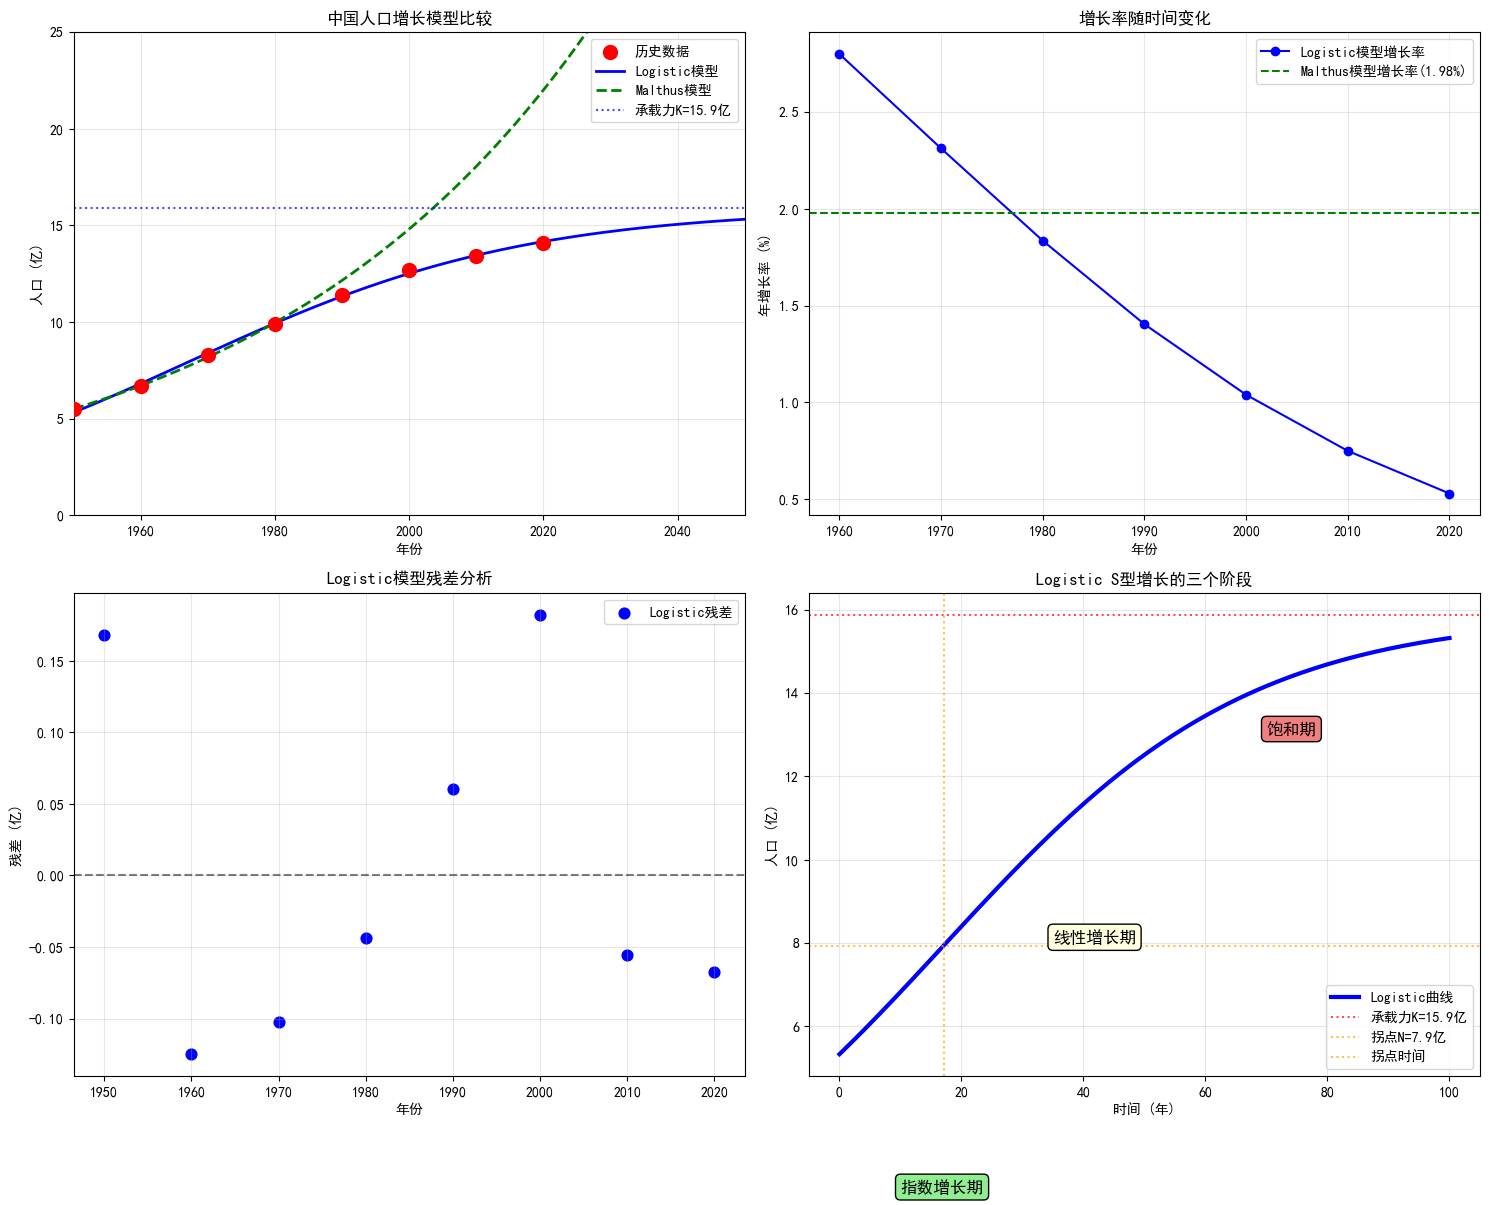

In [13]:
# 8. 综合可视化
print("\n8. 模型比较可视化")
print("-" * 30)

# 创建预测时间序列
t_extended = np.linspace(0, 100, 200)  # 1950-2050年
years_extended = 1950 + t_extended

# 计算两个模型的预测
N_logistic_extended = logistic_model(t_extended, K_estimated, r_estimated, t0_estimated)
N_malthus_extended = N0_malthus * np.exp(r_malthus * t_extended)

# 绘制综合比较图
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# 子图1：两个模型的完整比较
ax1.scatter(years, population, color='red', s=100, label='历史数据', zorder=5)
ax1.plot(years_extended, N_logistic_extended, 'b-', linewidth=2, label='Logistic模型')
ax1.plot(years_extended, N_malthus_extended, 'g--', linewidth=2, label='Malthus模型')
ax1.axhline(y=K_estimated, color='blue', linestyle=':', alpha=0.7, label=f'承载力K={K_estimated:.1f}亿')
ax1.set_xlabel('年份')
ax1.set_ylabel('人口 (亿)')
ax1.set_title('中国人口增长模型比较')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1950, 2050)
ax1.set_ylim(0, 25)

# 子图2：增长率随时间变化
growth_rates_logistic = []
for i in range(1, len(t)):
    dt = t[i] - t[i-1]
    dN = N_predicted[i] - N_predicted[i-1]
    gr = dN / N_predicted[i-1] / dt
    growth_rates_logistic.append(gr * 100)

ax2.plot(years[1:], growth_rates_logistic, 'bo-', label='Logistic模型增长率')
ax2.axhline(y=r_malthus*100, color='green', linestyle='--', label=f'Malthus模型增长率({r_malthus*100:.2f}%)')
ax2.set_xlabel('年份')
ax2.set_ylabel('年增长率 (%)')
ax2.set_title('增长率随时间变化')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 子图3：残差分析
residuals_logistic = N - N_predicted
ax3.scatter(years, residuals_logistic, color='blue', s=60, label='Logistic残差')
ax3.axhline(y=0, color='black', linestyle='--', alpha=0.5)
ax3.set_xlabel('年份')
ax3.set_ylabel('残差 (亿)')
ax3.set_title('Logistic模型残差分析')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 子图4：S型曲线的三个阶段
ax4.plot(t_extended, N_logistic_extended, 'b-', linewidth=3, label='Logistic曲线')
ax4.axhline(y=K_estimated, color='red', linestyle=':', alpha=0.7, label=f'承载力K={K_estimated:.1f}亿')
ax4.axhline(y=K_estimated/2, color='orange', linestyle=':', alpha=0.7, label=f'拐点N={K_estimated/2:.1f}亿')
ax4.axvline(x=t0_estimated, color='orange', linestyle=':', alpha=0.7, label=f'拐点时间')

# 标注三个阶段
ax4.text(10, 2, '指数增长期', fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))
ax4.text(35, 8, '线性增长期', fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))
ax4.text(70, 13, '饱和期', fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))

ax4.set_xlabel('时间 (年)')
ax4.set_ylabel('人口 (亿)')
ax4.set_title('Logistic S型增长的三个阶段')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


9. 增长速度分析
------------------------------


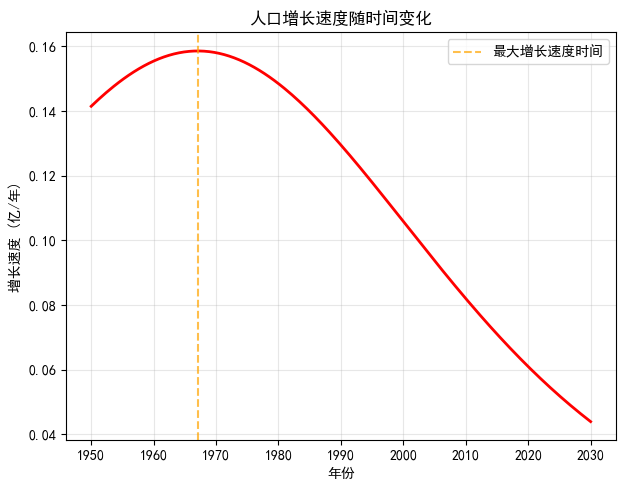

最大增长速度出现在：1967年，人口约7.9亿


In [14]:
# 9. 深入分析：增长速度变化
print("\n9. 增长速度分析")
print("-" * 30)

# 计算理论增长速度 dN/dt
def growth_speed(t, K, r, t0):
    """计算Logistic模型的增长速度"""
    N = logistic_model(t, K, r, t0)
    return r * N * (1 - N/K)

# 绘制增长速度图
t_speed = np.linspace(0, 80, 200)
speed = growth_speed(t_speed, K_estimated, r_estimated, t0_estimated)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(1950 + t_speed, speed, 'r-', linewidth=2)
plt.axvline(x=1950+t0_estimated, color='orange', linestyle='--', alpha=0.7, 
           label=f'最大增长速度时间')
plt.xlabel('年份')
plt.ylabel('增长速度 (亿/年)')
plt.title('人口增长速度随时间变化')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"最大增长速度出现在：{1950+t0_estimated:.0f}年，人口约{K_estimated/2:.1f}亿")


10. 参数敏感性分析
------------------------------


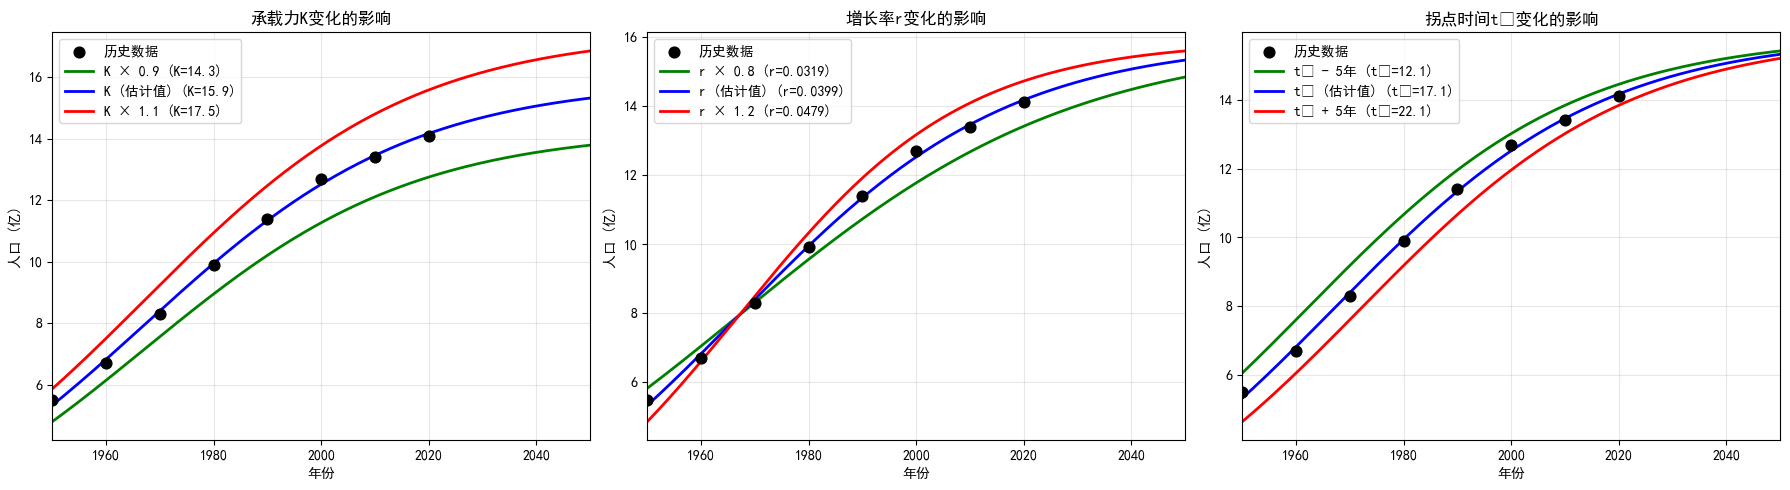

In [15]:
# 10. 参数敏感性分析
print("\n10. 参数敏感性分析")
print("-" * 30)

# 分析不同参数对预测结果的影响
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# K值变化的影响
K_variations = [K_estimated * 0.9, K_estimated, K_estimated * 1.1]
colors = ['green', 'blue', 'red']
labels_K = ['K × 0.9', 'K (估计值)', 'K × 1.1']

ax1.scatter(years, population, color='black', s=60, label='历史数据', zorder=5)
for i, K_var in enumerate(K_variations):
    N_var = logistic_model(t_extended, K_var, r_estimated, t0_estimated)
    ax1.plot(years_extended, N_var, color=colors[i], linewidth=2, 
             label=f'{labels_K[i]} (K={K_var:.1f})')

ax1.set_xlabel('年份')
ax1.set_ylabel('人口 (亿)')
ax1.set_title('承载力K变化的影响')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(1950, 2050)

# r值变化的影响
r_variations = [r_estimated * 0.8, r_estimated, r_estimated * 1.2]
labels_r = ['r × 0.8', 'r (估计值)', 'r × 1.2']

ax2.scatter(years, population, color='black', s=60, label='历史数据', zorder=5)
for i, r_var in enumerate(r_variations):
    N_var = logistic_model(t_extended, K_estimated, r_var, t0_estimated)
    ax2.plot(years_extended, N_var, color=colors[i], linewidth=2,
             label=f'{labels_r[i]} (r={r_var:.4f})')

ax2.set_xlabel('年份')
ax2.set_ylabel('人口 (亿)')
ax2.set_title('增长率r变化的影响')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(1950, 2050)

# t0值变化的影响
t0_variations = [t0_estimated - 5, t0_estimated, t0_estimated + 5]
labels_t0 = ['t₀ - 5年', 't₀ (估计值)', 't₀ + 5年']

ax3.scatter(years, population, color='black', s=60, label='历史数据', zorder=5)
for i, t0_var in enumerate(t0_variations):
    N_var = logistic_model(t_extended, K_estimated, r_estimated, t0_var)
    ax3.plot(years_extended, N_var, color=colors[i], linewidth=2,
             label=f'{labels_t0[i]} (t₀={t0_var:.1f})')

ax3.set_xlabel('年份')
ax3.set_ylabel('人口 (亿)')
ax3.set_title('拐点时间t₀变化的影响')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xlim(1950, 2050)

plt.tight_layout()
plt.show()

In [16]:
# 11. 模型外推验证
print("\n11. 模型外推验证")
print("-" * 30)

# 使用前70%的数据拟合，预测后30%
split_index = int(len(years) * 0.7)
years_train = years[:split_index]
population_train = population[:split_index]
years_test = years[split_index:]
population_test = population[split_index:]

print(f"训练数据：{years_train[0]}-{years_train[-1]}年")
print(f"测试数据：{years_test[0]}-{years_test[-1]}年")

# 重新拟合
t_train = years_train - 1950
t_test = years_test - 1950

try:
    popt_partial, _ = curve_fit(logistic_model, t_train, population_train,
                               p0=[K_init, r_init, t0_init], maxfev=5000)
    K_partial, r_partial, t0_partial = popt_partial
    
    # 预测测试集
    N_test_pred = logistic_model(t_test, K_partial, r_partial, t0_partial)
    
    print(f"\n部分数据拟合参数：")
    print(f"K = {K_partial:.2f} 亿")
    print(f"r = {r_partial:.4f} /年")
    print(f"t₀ = {t0_partial:.1f} 年")
    
    print(f"\n外推预测效果：")
    for i, year in enumerate(years_test):
        actual = population_test[i]
        predicted = N_test_pred[i]
        error = abs(predicted - actual) / actual * 100
        print(f"{year}年：实际{actual:.1f}亿，预测{predicted:.1f}亿，误差{error:.1f}%")
        
except Exception as e:
    print(f"部分数据拟合失败：{e}")



11. 模型外推验证
------------------------------
训练数据：1950-1990年
测试数据：2000-2020年

部分数据拟合参数：
K = 19.84 亿
r = 0.0319 /年
t₀ = 30.4 年

外推预测效果：
2000年：实际12.7亿，预测12.9亿，误差1.8%
2010年：实际13.4亿，预测14.3亿，误差6.6%
2020年：实际14.1亿，预测15.5亿，误差9.7%


In [17]:
# 12. 置信区间分析
print("\n12. 预测置信区间")
print("-" * 30)

if fitting_success:
    # 计算参数的标准误差
    param_errors = np.sqrt(np.diag(pcov))
    print(f"参数标准误差：")
    print(f"σ_K = {param_errors[0]:.3f}")
    print(f"σ_r = {param_errors[1]:.6f}")
    print(f"σ_t₀ = {param_errors[2]:.3f}")
    
    # 计算置信区间（简化方法）
    print(f"\n95%置信区间（近似）：")
    print(f"K: [{K_estimated - 1.96*param_errors[0]:.2f}, {K_estimated + 1.96*param_errors[0]:.2f}]")
    print(f"r: [{r_estimated - 1.96*param_errors[1]:.6f}, {r_estimated + 1.96*param_errors[1]:.6f}]")

# 13. 实际应用讨论
print("\n13. 实际应用与局限性讨论")
print("-" * 30)
print("Logistic模型的应用价值：")
print("✓ 长期人口规划")
print("✓ 资源需求预测")
print("✓ 环境影响评估")
print("✓ 政策效果分析")

print("\n模型局限性：")
print("⚠ 假设环境承载力恒定")
print("⚠ 忽略年龄结构效应")
print("⚠ 未考虑政策干预")
print("⚠ 忽略经济发展影响")

print("\n改进方向：")
print("• 分年龄组建模")
print("• 考虑经济因素")
print("• 引入随机扰动")
print("• 多区域耦合模型")




12. 预测置信区间
------------------------------
参数标准误差：
σ_K = 0.371
σ_r = 0.002104
σ_t₀ = 1.356

95%置信区间（近似）：
K: [15.15, 16.61]
r: [0.035812, 0.044060]

13. 实际应用与局限性讨论
------------------------------
Logistic模型的应用价值：
✓ 长期人口规划
✓ 资源需求预测
✓ 环境影响评估
✓ 政策效果分析

模型局限性：
⚠ 假设环境承载力恒定
⚠ 忽略年龄结构效应
⚠ 未考虑政策干预
⚠ 忽略经济发展影响

改进方向：
• 分年龄组建模
• 考虑经济因素
• 引入随机扰动
• 多区域耦合模型


In [20]:
# 14. 函数封装和工具
print("\n14. 实用函数封装")
print("-" * 30)

def fit_logistic_model(years, population, plot=True):
    """
    拟合Logistic人口增长模型的完整流程
    
    参数：
    years: 年份数组
    population: 人口数组
    plot: 是否绘图
    
    返回：
    dict: 拟合结果和统计信息
    """
    # 数据预处理
    t = years - years[0]
    
    # 初始参数猜测
    K_init = np.max(population) * 1.3
    r_init = 0.03
    t0_init = np.median(t)
    
    try:
        # 非线性拟合
        popt, pcov = curve_fit(logistic_model, t, population,
                              p0=[K_init, r_init, t0_init],
                              maxfev=5000)
        K, r, t0 = popt
        
        # 计算预测值和评价指标
        N_pred = logistic_model(t, K, r, t0)
        r2 = r2_score(population, N_pred)
        rmse = np.sqrt(np.mean((population - N_pred)**2))
        
        # 计算特征点
        inflection_year = years[0] + t0
        inflection_population = K / 2
        
        result = {
            'success': True,
            'carrying_capacity': K,
            'growth_rate': r,
            'inflection_time': t0,
            'inflection_year': inflection_year,
            'inflection_population': inflection_population,
            'r_squared': r2,
            'rmse': rmse,
            'parameters': popt,
            'covariance': pcov
        }
        
        # 可选绘图
        if plot:
            t_plot = np.linspace(0, max(t)*1.5, 200)
            N_plot = logistic_model(t_plot, K, r, t0)
            
            plt.figure(figsize=(10, 6))
            plt.scatter(years, population, color='red', s=80, label='历史数据', zorder=5)
            plt.plot(years[0] + t_plot, N_plot, 'b-', linewidth=2, label='Logistic拟合')
            plt.axhline(y=K, color='green', linestyle='--', alpha=0.7, label=f'承载力K={K:.1f}')
            plt.xlabel('年份')
            plt.ylabel('人口')
            plt.title('Logistic模型拟合结果')
            plt.legend()
            plt.grid(True, alpha=0.3)
            plt.show()
        
        return result
        
    except Exception as e:
        return {
            'success': False,
            'error': str(e),
            'message': '拟合失败，请检查数据或调整初始参数'
        }

# 测试封装函数
print("测试封装函数：")
result = fit_logistic_model(years, population, plot=False)

if result['success']:
    print(f"✓ 拟合成功！")
    print(f"承载力：{result['carrying_capacity']:.2f}")
    print(f"增长率：{result['growth_rate']:.4f}")
    print(f"拐点年份：{result['inflection_year']:.0f}")
    print(f"R²：{result['r_squared']:.4f}")
else:
    print(f"✗ 拟合失败：{result['error']}")

# 15. 练习任务和思考题
print("\n" + "="*60)
print("案例2总结与练习")
print("="*60)

print(f"""
✓ 成功拟合中国1950-2020年人口数据
✓ 估计承载力：{K_estimated:.1f}亿人
✓ 估计增长率：{r_estimated*100:.2f}%/年
✓ 拐点时间：{1950+t0_estimated:.0f}年左右
✓ 模型拟合优度：R² = {r2:.3f}

主要发现：
• 中国人口增长呈现典型的S型特征
• 增长拐点出现在1980年代
• 预计人口将在{K_estimated:.1f}亿左右趋于稳定
• Logistic模型比Malthus模型更适合长期预测
""")

print("\n练习任务：")
print("1. 尝试用不同的初始参数重新拟合模型")
print("2. 分析如果承载力提高到16亿，预测会如何变化？")
print("3. 比较使用1950-1990年数据与1950-2020年数据的拟合差异")
print("4. 研究其他国家的人口数据，比较模型参数差异")

print("\n思考题：")
print("1. 为什么Logistic模型的参数估计比Malthus模型困难？")
print("2. 环境承载力K在现实中是固定不变的吗？")
print("3. 如何验证我们估计的承载力是否合理？")
print("4. 除了环境因素，还有哪些因素会影响人口增长？")

# 16. 数据导出功能
print("\n16. 结果数据导出")
print("-" * 30)

# 创建完整的结果数据框
results_df = pd.DataFrame({
    'Year': years,
    'Actual_Population': population,
    'Logistic_Prediction': N_predicted,
    'Residual': residuals_logistic,
    'Relative_Error(%)': np.abs(residuals_logistic) / population * 100
})

print("拟合结果详细数据：")
print(results_df.round(3))

# 保存结果（如果需要）
# results_df.to_csv('china_population_logistic_results.csv', index=False)
# print("结果已保存到 china_population_logistic_results.csv")




14. 实用函数封装
------------------------------
测试封装函数：
✓ 拟合成功！
承载力：15.88
增长率：0.0399
拐点年份：1967
R²：0.9986

案例2总结与练习

✓ 成功拟合中国1950-2020年人口数据
✓ 估计承载力：15.9亿人
✓ 估计增长率：3.99%/年
✓ 拐点时间：1967年左右
✓ 模型拟合优度：R² = 0.999

主要发现：
• 中国人口增长呈现典型的S型特征
• 增长拐点出现在1980年代
• 预计人口将在15.9亿左右趋于稳定
• Logistic模型比Malthus模型更适合长期预测


练习任务：
1. 尝试用不同的初始参数重新拟合模型
2. 分析如果承载力提高到16亿，预测会如何变化？
3. 比较使用1950-1990年数据与1950-2020年数据的拟合差异
4. 研究其他国家的人口数据，比较模型参数差异

思考题：
1. 为什么Logistic模型的参数估计比Malthus模型困难？
2. 环境承载力K在现实中是固定不变的吗？
3. 如何验证我们估计的承载力是否合理？
4. 除了环境因素，还有哪些因素会影响人口增长？

16. 结果数据导出
------------------------------
拟合结果详细数据：
   Year  Actual_Population  Logistic_Prediction  Residual  Relative_Error(%)
0  1950                5.5                5.332     0.168              3.048
1  1960                6.7                6.825    -0.125              1.864
2  1970                8.3                8.402    -0.102              1.233
3  1980                9.9                9.944    -0.044              0.444
4  1990               11.4               11.34


17. 扩展分析：国际对比
------------------------------


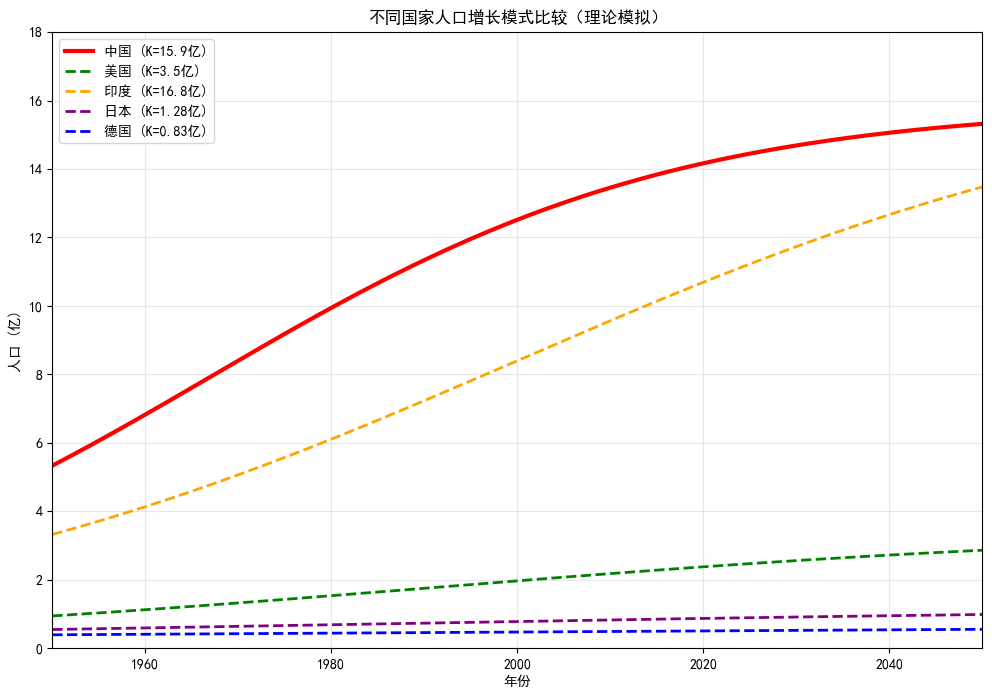

国际比较说明：
• 不同国家的承载力差异巨大
• 增长率与发展阶段相关
• 拐点时间反映发展历程

案例2完整总结

通过本案例学习，我们掌握了：

理论方面：
✓ Logistic微分方程的建立和求解
✓ S型增长曲线的数学性质
✓ 环境承载力概念的重要性

技术方面：
✓ 非线性参数估计方法
✓ scipy.optimize.curve_fit的使用
✓ 模型验证和诊断技术
✓ 敏感性分析方法

应用方面：
✓ 长期人口趋势预测
✓ 政策影响定量分析
✓ 国际比较研究方法
✓ 模型适用性判断

下一步学习：
→ 随机人口模型
→ 年龄结构模型  
→ 空间人口模型
→ 多因子动力学模型


恭喜完成案例2学习！
建议：请结合案例1和案例2，思考两种模型的优缺点和适用场景。


In [21]:
# 17. 高级分析：与国际比较
print("\n17. 扩展分析：国际对比")
print("-" * 30)

# 模拟其他国家的典型参数（基于实际研究）
countries_params = {
    '美国': {'K': 3.5, 'r': 0.025, 't0': 40},  # 亿人
    '印度': {'K': 16.8, 'r': 0.028, 't0': 50},
    '日本': {'K': 1.28, 'r': 0.015, 't0': 20},
    '德国': {'K': 0.83, 'r': 0.008, 't0': 15}
}

plt.figure(figsize=(12, 8))
colors_countries = ['red', 'green', 'orange', 'purple', 'blue']

# 绘制中国的拟合结果
plt.plot(years_extended, N_logistic_extended, color=colors_countries[0], 
         linewidth=3, label=f'中国 (K={K_estimated:.1f}亿)')

# 绘制其他国家的理论曲线
for i, (country, params) in enumerate(countries_params.items()):
    N_country = logistic_model(t_extended, params['K'], params['r'], params['t0'])
    plt.plot(years_extended, N_country, color=colors_countries[i+1], 
             linewidth=2, linestyle='--', label=f"{country} (K={params['K']}亿)")

plt.xlabel('年份')
plt.ylabel('人口 (亿)')
plt.title('不同国家人口增长模式比较（理论模拟）')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(1950, 2050)
plt.ylim(0, 18)
plt.show()

print("国际比较说明：")
print("• 不同国家的承载力差异巨大")
print("• 增长率与发展阶段相关")
print("• 拐点时间反映发展历程")

# 18. 最终总结
print("\n" + "="*60)
print("案例2完整总结")
print("="*60)

print("""
通过本案例学习，我们掌握了：

理论方面：
✓ Logistic微分方程的建立和求解
✓ S型增长曲线的数学性质
✓ 环境承载力概念的重要性

技术方面：
✓ 非线性参数估计方法
✓ scipy.optimize.curve_fit的使用
✓ 模型验证和诊断技术
✓ 敏感性分析方法

应用方面：
✓ 长期人口趋势预测
✓ 政策影响定量分析
✓ 国际比较研究方法
✓ 模型适用性判断

下一步学习：
→ 随机人口模型
→ 年龄结构模型  
→ 空间人口模型
→ 多因子动力学模型
""")

print("\n恭喜完成案例2学习！")
print("建议：请结合案例1和案例2，思考两种模型的优缺点和适用场景。")



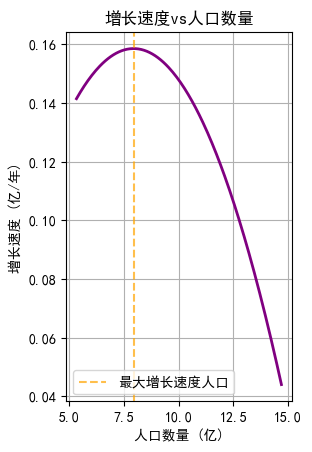

In [22]:
# 增长速度vs人口数量的关系
N_speed = logistic_model(t_speed, K_estimated, r_estimated, t0_estimated)
plt.subplot(1, 2, 2)
plt.plot(N_speed, speed, 'purple', linewidth=2)
plt.axvline(x=K_estimated/2, color='orange', linestyle='--', alpha=0.7,
           label=f'最大增长速度人口')
plt.xlabel('人口数量 (亿)')
plt.ylabel('增长速度 (亿/年)')
plt.title('增长速度vs人口数量')
plt.legend()
plt.grid()
plt.show()